# BASE 1 — Episodios (Internaciones)

In [ ]:
# 0. IMPORTS Y CONFIGURACIÓN INICIAL
# ==============================================================================
import sys
import os
sys.path.append(os.path.abspath(".."))

import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from src.config import *

In [ ]:
# 1. CARGA Y RENOMBRE COMPLETO (PRESERVACIÓN TOTAL)
# Se cargan los datos crudos y se estandariza la nomenclatura básica sin borrar nada.
# ==============================================================================
df_raw = pd.read_excel("../data/pacientes.xlsx")
hospitales = pd.read_csv("../data/hospitales_coordenadas.csv")

dict_comp = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))
hospitales['color_rgb'] = hospitales['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df_base = df_raw.rename(columns={
    'Id Hospital': 'hospital_id', 'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id', 'Fecha inicio': 'fecha_ingreso', 'Fecha egreso': 'fecha_egreso',
    'Estado al ingreso': 'estado_ingreso', 'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo', 'Último tipo': 'tipo_ultimo',
    'Sexo': 'sexo', 'Edad': 'edad', 'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social', 'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria', 'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis', '1º dosis': 'fecha_dosis_1', '2º dosis': 'fecha_dosis_2',
    'Buscado en el ministerio': 'validado_ministerio', 'Obra social': 'obra_social',
    'Asistencia Respiratoria Mecánica': 'requiere_arm', 'Motivo': 'motivo_egreso',
    'Operación': 'operacion', 'Última actualización': 'fecha_ultima_actualizacion',
    'Pasó por Críticas': 'paso_criticas', 'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

# Estandarización básica y NORMALIZACION
df_base['hospital_origen'] = df_base['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
}).str.strip()

df_base['fecha_ingreso'] = pd.to_datetime(df_base['fecha_ingreso'], errors='coerce').dt.normalize()
df_base['fecha_egreso'] = pd.to_datetime(df_base['fecha_egreso'], errors='coerce').dt.normalize()
df_base['edad'] = pd.to_numeric(df_base['edad'], errors='coerce')

df_base['dias_en_nodo'] = ((df_base['fecha_egreso'] - df_base['fecha_ingreso']).dt.days)

np.float64(-325.0)

In [15]:
#  2. ADICIÓN DE FLAGS (Categoría 3 y 4) SOBRE DF_BASE ORIGINAL
# Se marcan anomalías clínicas y administrativas sin destruir la fila original.
# ==============================================================================
# Categoría 3: Flags de Calidad Clínica
df_base['flag_edad_rara'] = (df_base['edad'] < 0) | (df_base['edad'] > 110)
df_base['flag_duracion_negativa'] = df_base['dias_en_nodo'] < 0
df_base['flag_duracion_larga'] = df_base['dias_en_nodo'] > 60

# Categoría 4: Flags de Validez Administrativa
df_base['motivo_egreso_clean'] = (
    df_base['motivo_egreso'].astype(str).str.lower().str.strip()
)

df_base['flag_egreso_admin_invalido'] = df_base['motivo_egreso_clean'].str.contains(
    'anulado|error|duplicado', case=False, na=False
)

def clasificar_egreso(x):
    if pd.isna(x): return 'desconocido'
    x = str(x).lower()
    if 'muerte' in x: return 'muerte'
    elif 'alta-domiciliaria' in x: return 'alta'
    elif 'traslado-extra-sanitario' in x: return 'hotel'
    elif 'traslado-otro' in x: return 'hospital-externo'
    elif 'traslado-hospital-de-la-red' in x: return 'traslado'
    elif 'anulado' in x or 'otro' in x: return 'administrativo'
    else: return 'administrativo'

df_base['tipo_egreso'] = df_base['motivo_egreso'].apply(clasificar_egreso)

# Ordenamiento de toda la base original antes de filtrar
df_base = df_base.sort_values(['paciente_id', 'fecha_ingreso'])

In [16]:
#  3. CREACIÓN DE MÁSCARAS Y FILTRADO FINAL (Categoría 1 y 2)
# Se aplican los filtros duros para eliminar registros físicamente imposibles o incompletos.
# ==============================================================================
# Categoría 1: Integridad Estructural (Mask)
mask_integridad_core = (
    df_base['paciente_id'].notna() &
    df_base['hospital_origen'].notna() &
    (df_base['hospital_origen'] != '') &
    df_base['fecha_egreso'].notna() &
    df_base['fecha_ingreso'].notna()
)

# Categoría 2: Coherencia Lógica (Mask)
mask_fechas_logicas = (
    (df_base['fecha_ingreso'] <= df_base['fecha_egreso'])
)

# Filtro destructivo solo para generar df_base_limpia
df_base_limpia = df_base[
    mask_integridad_core & 
    mask_fechas_logicas
].copy()

In [17]:
# 4. EXPORTACIÓN DE BASE LIMPIA
# Se guarda la base procesada para ser utilizada por los siguientes notebooks.
# ==============================================================================
df_base_limpia.to_excel("../data/final_data/df_base_limpia.xlsx", index=False)
# df_base_limpia.to_parquet("../data/final_data/df_base_limpia.parquet", index=False)

-----------------------------------
## 7. SANITY CHECKS Y EDA (Opcional / Para mover a otro Notebook)
#### Sección confinada de visualizaciones y exploración de los datos resultantes.
------------------------------

In [18]:
# --- A. RESUMEN BÁSICO DE CALIDAD ---
print("Total episodios crudos:", len(df_base))
print("Episodios válidos (tras Filtros Duros):", len(df_base_limpia))
print("\n% flag_edad_rara:", df_base_limpia['flag_edad_rara'].mean())
print("% sin fecha egreso (debe ser 0.0):", df_base_limpia['fecha_egreso'].isna().mean())
print("% flag_egreso_admin_invalido:", df_base_limpia['flag_egreso_admin_invalido'].mean())
print("\nDuración (días) resumen:")
print(df_base_limpia['dias_en_nodo'].describe())
print("\nTop hospitales:")
print(df_base_limpia['hospital_origen'].value_counts().head(10))
print("\nProporción por tipo_egreso:")
print(df_base_limpia['tipo_egreso'].value_counts(normalize=True))
print("\nColumnas con mayor % de nulos:")
print(df_base_limpia.isna().mean().sort_values(ascending=False).head(10))

# --- B. CASOS ATÍPICOS EN DURACIÓN ---
cols_revisar = [
    'paciente_id', 'hospital_origen', 'fecha_ingreso', 
    'fecha_egreso', 'dias_en_nodo', 'motivo_egreso', 'tipo_egreso'
]

print("\n--- Paciente(s) con la internación más larga ---")
print(df_base_limpia.loc[
    df_base_limpia['dias_en_nodo'] == df_base_limpia['dias_en_nodo'].max(), cols_revisar
])

print("\n--- Top 10 estancias más largas ---")
print(df_base_limpia.nlargest(10, 'dias_en_nodo')[cols_revisar])

print("\n--- Top 10 estancias más cortas ---")
print(df_base_limpia.nsmallest(10, 'dias_en_nodo')[cols_revisar])

duracion_minutos = (df_base_limpia['fecha_egreso'] - df_base_limpia['fecha_ingreso']).dt.total_seconds() / 60
errores_tiempo = df_base_limpia[duracion_minutos <= 2]
print(f"\nDetectados {len(errores_tiempo)} registros con duración <= 2 minutos.")

# --- C. BÚSQUEDA DE POTENCIALES DUPLICADOS O SUPERPOSICIONES ---
print("\n--- Pacientes con más episodios ---")
print(df_base_limpia['paciente_id'].value_counts().head(10))

print("\n--- Posibles duplicados exactos (mismo ID, Hospital y Fecha Ingreso) ---")
print(df_base_limpia[
    df_base_limpia.duplicated(
        subset=['paciente_id', 'hospital_origen', 'fecha_ingreso'], 
        keep=False
    )
].sort_values(['paciente_id', 'fecha_ingreso']).head(10))

print("\n--- Hospitales con mayor duración de estadía media ---")
print(df_base_limpia.groupby('hospital_origen')['dias_en_nodo'].mean().sort_values(ascending=False).head(10))

Total episodios crudos: 29697
Episodios válidos (tras Filtros Duros): 24954

% flag_edad_rara: 0.004368037188426705
% sin fecha egreso (debe ser 0.0): 0.0
% flag_egreso_admin_invalido: 0.022842029333974515

Duración (días) resumen:
count    24954.000000
mean         9.779114
std         18.123682
min          0.000000
25%          2.000000
50%          5.000000
75%         11.000000
max        553.000000
Name: dias_en_nodo, dtype: float64

Top hospitales:
hospital_origen
Mi Pueblo                      4267
Oñativia                       3556
UPA 5 - AB                     3019
Lucio Meléndez                 2788
Oller                          1658
Módulo Hospitalario 11 - FV    1604
UPA 11 - FV                    1541
Evita Pueblo                   1461
El Cruce                       1321
Módulo Hospitalario 10 - QU    1178
Name: count, dtype: int64

Proporción por tipo_egreso:
tipo_egreso
alta                0.575779
administrativo      0.111044
muerte              0.107959
hospital-e

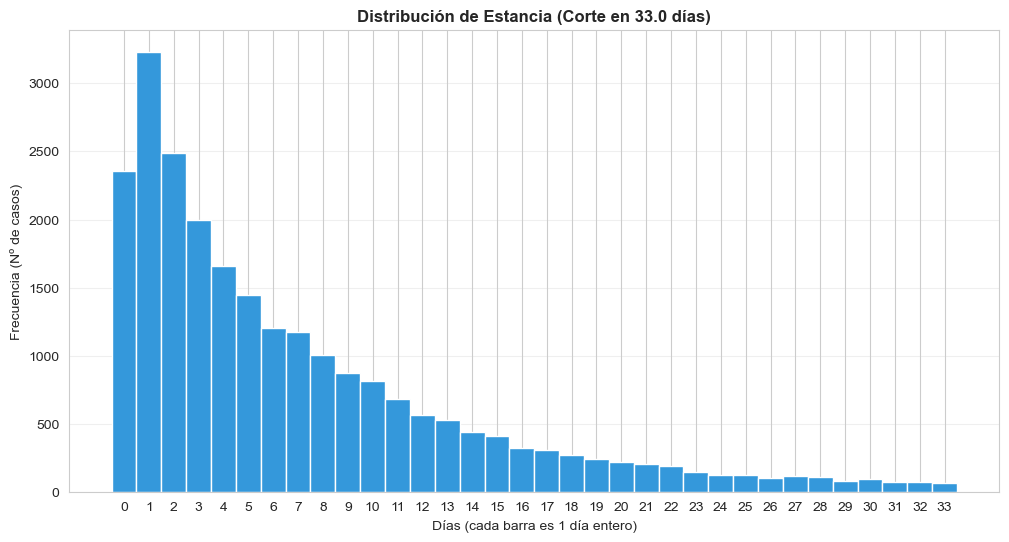

✅ ¡Los 3 gráficos se generaron en ../data/final_data/!


In [19]:
# --- D. VISUALIZACIÓN DE DURACIÓN ---
limite_outliers = df_base_limpia['dias_en_nodo'].quantile(0.95)
df_filtrado = df_base_limpia[df_base_limpia['dias_en_nodo'] <= limite_outliers]
valor_max = int(df_filtrado['dias_en_nodo'].max())
bins = np.arange(0, valor_max + 2) - 0.5

plt.figure(figsize=(12, 6))
plt.hist(df_filtrado['dias_en_nodo'], bins=bins, edgecolor='white', color='#3498db')
plt.xticks(range(0, valor_max + 1))
plt.title(f'Distribución de Estancia (Corte en {limite_outliers:.1f} días)')
plt.xlabel('Días (cada barra es 1 día entero)')
plt.ylabel('Frecuencia (Nº de casos)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- E. GENERACIÓN DE GRÁFICOS (Red y Dinámica) ---
plt.style.use('dark_background')
color_fondo = '#0a0a0c'
color_texto = '#A0A0B0'
color_cyan = '#00FFFF'
color_magenta = '#FF007F'

df_graf = df_base_limpia.sort_values(['paciente_id', 'fecha_ingreso']).copy()
df_graf['hospital_destino'] = df_graf.groupby('paciente_id')['hospital_origen'].shift(-1)
df_traslados = df_graf.dropna(subset=['hospital_destino'])
df_traslados = df_traslados[df_traslados['hospital_origen'] != df_traslados['hospital_destino']]

# Gráfico 1: Topología
df_rutas = df_traslados.groupby(['hospital_origen', 'hospital_destino']).size().reset_index(name='peso')
G = nx.DiGraph()
for _, row in df_rutas.iterrows():
    G.add_edge(row['hospital_origen'], row['hospital_destino'], weight=row['peso'])

fig1, ax1 = plt.subplots(figsize=(12, 12), dpi=150)
fig1.patch.set_facecolor(color_fondo)
ax1.set_facecolor(color_fondo)
pos = nx.spring_layout(G, k=0.9, iterations=100, seed=42)
pesos = [G[u][v]['weight'] for u, v in G.edges()]
max_peso = max(pesos) if pesos else 1
grosores_glow = [(w / max_peso) * 6 + 0.5 for w in pesos]
grados = [G.degree(nodo) for nodo in G.nodes()]
node_sizes = [g * 30 + 50 for g in grados]
nx.draw_networkx_edges(G, pos, edge_color=color_cyan, width=grosores_glow, alpha=0.3, ax=ax1, arrows=False)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=color_magenta, alpha=0.8, ax=ax1)
ax1.axis('off')
ax1.set_title("Topología de Derivaciones Hospitalarias", color=color_texto, fontsize=16, pad=20)
fig1.tight_layout()
fig1.savefig("../data/final_data/linkedin_01_red.png", facecolor=color_fondo, dpi=300)
plt.close(fig1)

# Gráfico 2: Patrones Temporales
df_traslados['dia_semana'] = df_traslados['fecha_ingreso'].dt.day_name()
df_traslados['mes'] = df_traslados['fecha_ingreso'].dt.month
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df_traslados.groupby(['dia_semana', 'mes']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(dias_orden)

fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=150)
fig2.patch.set_facecolor(color_fondo)
ax2.set_facecolor(color_fondo)
sns.heatmap(heatmap_data, cmap="crest_r", linewidths=0.5, linecolor=color_fondo, cbar=False, ax=ax2)
ax2.set_title("Intensidad de Derivaciones (Patrón Temporal)", color=color_texto, fontsize=14, pad=15)
ax2.set_xlabel("Evolución Temporal ->", color=color_texto)
ax2.set_ylabel("")
ax2.tick_params(colors=color_texto, labelsize=10)
ax2.set_xticks([]) 
ax2.set_yticks([]) 
fig2.tight_layout()
fig2.savefig("../data/final_data/linkedin_02_patrones.png", facecolor=color_fondo, dpi=300)
plt.close(fig2)

# Gráfico 3: Distribución
fig3, ax3 = plt.subplots(figsize=(10, 5), dpi=150)
fig3.patch.set_facecolor(color_fondo)
ax3.set_facecolor(color_fondo)
datos_estancia = df_base_limpia[df_base_limpia['dias_en_nodo'] < 30]['dias_en_nodo']
sns.kdeplot(datos_estancia, color=color_magenta, fill=True, alpha=0.4, linewidth=2, ax=ax3)
ax3.set_title("Distribución de Tiempos de Internación por Episodio", color=color_texto, fontsize=14, pad=15)
ax3.set_xlabel("Días de Estancia (Escala Relativa)", color=color_texto)
ax3.set_ylabel("Densidad de Pacientes", color=color_texto)
ax3.tick_params(colors=color_texto)
ax3.set_yticklabels([])
ax3.set_xticklabels([])
for spine in ax3.spines.values():
    spine.set_color('#333344')
fig3.tight_layout()
fig3.savefig("../data/final_data/linkedin_03_estancia.png", facecolor=color_fondo, dpi=300)
plt.close(fig3)

print("✅ ¡Los 3 gráficos se generaron en ../data/final_data/!")